Digits:           [0 1 2 3 4 5 6 7 8 9]
Actual Classes:   [0 1 0 1 0 1 0 1 0 1]
Predicted Classes: [0 1 0 1 0 1 0 1 0 1]


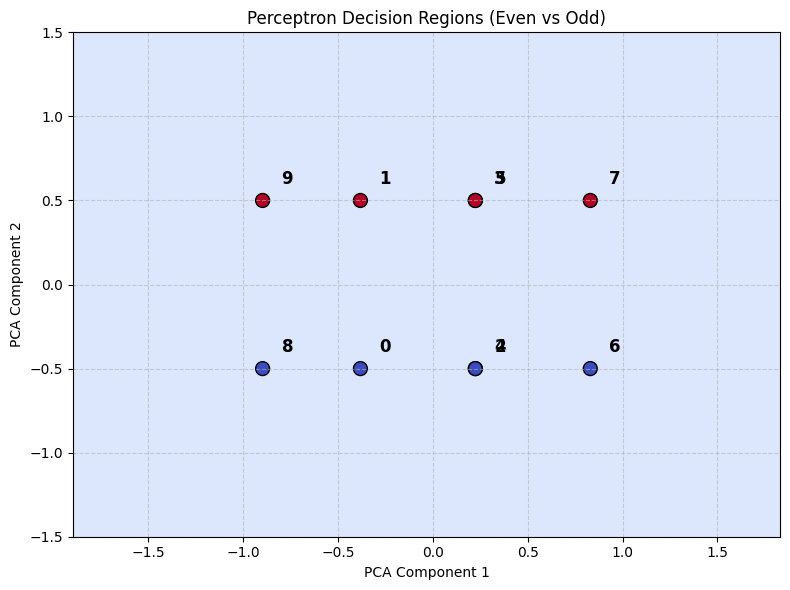

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA 

# 1. Data Preparation (Simplified)
digits = np.arange(10)
# One-liner to convert digits to 8-bit ASCII arrays
X = np.array([[int(b) for b in format(ord(str(d)), '08b')] for d in digits])
# Labels: 0 for Even, 1 for Odd
y = digits % 2 

# 2. Perceptron Initialization
np.random.seed(42) 
weights = np.random.randn(X.shape[1]) 
bias = np.random.randn() 
learning_rate = 0.1 
epochs = 50 

# Activation function as a simple lambda
step = lambda x: np.where(x >= 0, 1, 0)

# 3. Training Loop (Fixed Indentation)
for _ in range(epochs): 
    for xi, target in zip(X, y): 
        prediction = step(np.dot(xi, weights) + bias) 
        error = target - prediction 
        weights += learning_rate * error * xi 
        bias += learning_rate * error 

# 4. Evaluation (Vectorized instead of looped)
predictions = step(np.dot(X, weights) + bias)
print("Digits:          ", digits) 
print("Actual Classes:  ", y) 
print("Predicted Classes:", predictions) 

# 5. PCA & Visualization 
pca = PCA(n_components=2) 
X_2d = pca.fit_transform(X) 
w_pca = pca.transform([weights])[0] 

# Generate Meshgrid for Decision Boundary
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1 
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1 
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)) 

grid = np.c_[xx.ravel(), yy.ravel()] 
Z = step(np.dot(grid, w_pca[:2]) + bias).reshape(xx.shape) 

# Plotting
plt.figure(figsize=(8,6)) 
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm') 
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=100) 

for i, digit in enumerate(digits): 
    plt.text(X_2d[i, 0] + 0.1, X_2d[i, 1] + 0.1, str(digit), fontsize=12, fontweight='bold') 

plt.title("Perceptron Decision Regions (Even vs Odd)") 
plt.xlabel("PCA Component 1") 
plt.ylabel("PCA Component 2") 
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() 
plt.show()